In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
from common.consts import proteins, thresholds, res_colors

%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
from pathlib import Path
all_mfpt = {protein: {th: [] for th in thresholds} for protein in proteins}

def read_colvar_with_fields(path):
    with open(path, "r") as f:
        header = f.readline().strip()
    parts = header.split()
    if len(parts) < 3 or parts[0] != "#!" or parts[1] != "FIELDS":
        raise ValueError(f"Unexpected FIELDS header in {path}: {header}")
    names = parts[2:]
    return pd.read_csv(path, sep=r"\s+", comment="#", names=names, engine="python")

for protein in proteins:
    base_path = Path(f"../data/{protein}/output")
    for i in range(4000, 4201):
        index_str = f"{i:03}"
        run_path = base_path / f"run_{index_str}" / f"HLDA_COLVAR_{index_str}"
        try:
            df = read_colvar_with_fields(run_path)
        except FileNotFoundError:
            print(f"Missing: {run_path}")
            continue
        if not {"time", "metad.acc", "rmsd"}.issubset(df.columns):
            print(f"Missing required columns in {run_path}")
            continue

        passed = set()
        for _, row in df.iterrows():
            time = row["time"]
            acc = row["metad.acc"]
            rmsd = row["rmsd"]
            predicted = time * acc
            for th in thresholds:
                if th not in passed and rmsd > th:
                    all_mfpt[protein][th].append(predicted)
                    passed.add(th)
            if len(passed) == len(thresholds):
                break



In [3]:
import pickle

with open("../data/mfpt-pace=25000.pkl", "wb") as f:
    pickle.dump(all_mfpt, f)
print(all_mfpt['chignolin'].keys())

dict_keys([np.float64(0.1), np.float64(0.14), np.float64(0.18000000000000002), np.float64(0.22000000000000003), np.float64(0.26), np.float64(0.30000000000000004), np.float64(0.3400000000000001), np.float64(0.38), np.float64(0.42000000000000004), np.float64(0.4600000000000001), np.float64(0.5000000000000001)])


In [4]:
from itertools import cycle
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from STiMetaD import STiMetaD
import numpy as np
import pickle
from common.consts import groupByResidue, groupByProperty, mutation_map
from common.utils import estimateMFPT, iMetaDMFPT

short_to_residue = {short: idx for idx, shorts in groupByResidue.items() for short in shorts}
short_to_property = {short: prop for prop, shorts in groupByProperty.items() for short in shorts}

top5_evec_dot = pd.read_csv('../data/top5_evec_dot.csv', index_col='Mutant')
eigenvalue_data = pd.read_csv('../data/eigenvalues.csv', index_col='mutation')
full_evec_dot = pd.read_csv('../data/full_evec_dot.csv', index_col='Mutant')
avg_change_diff = pd.read_csv('../data/average_change_difference.csv', index_col='Mutant')
avg_change_folded = pd.read_csv('../data/average_change_folded.csv', index_col='Mutant')
avg_change_unfolded = pd.read_csv('../data/average_change_unfolded.csv', index_col='Mutant')
cov_dot_product = pd.read_csv('../data/cov_dot_products.csv', index_col='Mutant')
diagonal_cov_dot_products = pd.read_csv('../data/diagonal_cov_dot_products.csv', index_col='Mutant')
variance_differences = pd.read_csv('../data/variance_differences.csv', index_col='Mutant')


def collect_df(all_mfpt, th: float, sample_size: int):
    rows = []

    for long_name in proteins:
        short = mutation_map.get(long_name)
        if short is None:
            raise ValueError(f"Unknown mutation: {long_name}")
        s = np.sort(np.array(all_mfpt[long_name][th]))
        mfpt, lim = estimateMFPT(s)
        print(f"{long_name} ({short}): {(mfpt * 1e-6):.4g} us, extra: {lim:.4g}")

        rows.append({
            "long": long_name,
            "short": short,
            "eigenvalue": eigenvalue_data.loc[short, "eigenvalue"],
            "mfpt": mfpt,
            "lim": lim,
            "full_evec_dot": full_evec_dot['full_evec_dot'].get(short, None),
            "cos_sim_folded": cov_dot_product['CosSim_Folded'].get(short, None),
            "cos_sim_unfolded": cov_dot_product['CosSim_Unfolded'].get(short, None),
            "avg_change_diff": avg_change_diff['AvgChange_Diff_F-U'].get(short, None),
            "diagonal_cov_dot_folded": diagonal_cov_dot_products['Diagonal_Dot_Folded'].get(short, None),
            "diagonal_cov_dot_unfolded": diagonal_cov_dot_products['Diagonal_Dot_Unfolded'].get(short, None),
            "abs_dvar_folded": variance_differences['abs_dvar_F'].get(short, None),
            "avg_change_folded": avg_change_folded['AvgChange_Folded'].get(short, None),
            "avg_change_unfolded": avg_change_unfolded['AvgChange_Unfolded'].get(short, None),
            "abs_dvar_unfolded": variance_differences['abs_dvar_U'].get(short, None),
            "top5_evec_dot": top5_evec_dot['top5_evec_dot'].get(short, None),
            "residue_idx": short_to_residue.get(short),
            "property_grp": short_to_property.get(short),
        })

    df = pd.DataFrame(rows)
    df.set_index("short", inplace=True)
    return df

def color_map(keys):
    # stable color cycle
    base = cycle(plt.rcParams['axes.prop_cycle'].by_key().get('color', []))
    return {k: next(base) for k in keys}



chignolin (WT): 0.3267 us, extra: 27
YYCPETGTWY (D2C): 6.844 us, extra: 11
YYDPETGTWE (Y9E): 0.06242 us, extra: 15
YYRPETGTWY (D2R): 1.025 us, extra: 11
YYAPETGTWY (D2A): 1.089 us, extra: 14
YYDPETGQWY (T7Q): 8.982 us, extra: 11
YYDPETGTWG (Y9G): 0.01831 us, extra: 10
YYDPETGTWQ (Y9Q): 0.1023 us, extra: 5
YYNPETGTWY (D2N): 0.3716 us, extra: 16
YYEPETGTWY (D2E): 2.34 us, extra: 15
YYDPETGTWR (Y9R): 0.3414 us, extra: 13
YYDPETGVWY (T7V): 1.86 us, extra: 23
YYDPETGYWY (T7Y): 0.8552 us, extra: 46
YYDPETGTWV (Y9V): 0.1636 us, extra: 51
YYDPETGRWY (T7R): 11.73 us, extra: 6
YYDPETGTWA (Y9A): 0.03151 us, extra: 55
YYDPETGGWY (T7G): 0.1885 us, extra: 23
YYMPETGTWY (D2M): 3.293 us, extra: 12
0.18000000000000002
p: 0.0021637139301120367


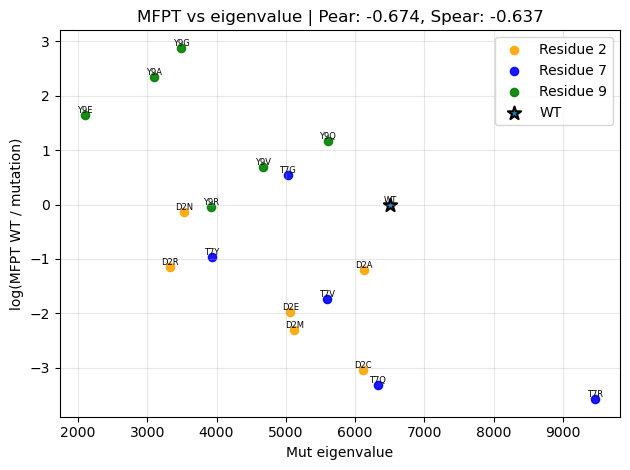

(np.float64(-0.6739400790775933), np.float64(-0.6367389060887513))

In [12]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
def plot_mfpt_corr(df, prop_col, wt_label='WT', group_col='residue_idx',
                   annotate=False, th=None, log_prop=True):
    wt_mfpt = float(df.loc[wt_label, 'mfpt'])
    wt_prop = df.loc[wt_label, prop_col]

    def ratio_or_raw(wt, arr):
        arr = np.asarray(arr, float)
        if pd.isna(wt):
            return arr
        return wt - arr

    x_all = df[prop_col].to_numpy()
    y_all = np.log(wt_mfpt / df['mfpt'].to_numpy())
    mask = np.isfinite(x_all) & np.isfinite(y_all)

    pearson, p  = stats.pearsonr(x_all[mask], y_all[mask])
    print(f"p: {p}")
    spearman, _ = stats.spearmanr(x_all[mask], y_all[mask])

    res_keys = sorted(int(k) for k in df[group_col].dropna().unique())

    for xv, yv, name in zip(x_all[mask], y_all[mask], df.index.to_numpy()):
        plt.text(xv, yv, name, fontsize=6, ha='center', va='bottom')

    for k in res_keys:
        sub = df[df[group_col] == k]
        x = sub[prop_col].to_numpy()
        y = np.log(wt_mfpt / sub['mfpt'].to_numpy())
        plt.scatter(x, y, label=f"Residue {k}", s=35, alpha=0.9, c=res_colors.get(k))

    plt.scatter(wt_prop, 0, s=100, marker='*',
                    edgecolors='k', linewidths=1.5, label=wt_label)

    xlabel = (f'Mut {prop_col}'
              if log_prop and not pd.isna(wt_prop)
              else prop_col)
    plt.xlabel(xlabel)
    plt.ylabel('log(MFPT WT / mutation)')
    t = f" | Th={th:.3g}" if th is not None else ""
    plt.title(f"MFPT vs {prop_col} | Pear: {pearson:.3g}, Spear: {spearman:.3g}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return pearson, spearman


with open("../data/mfpt-pace=25000.pkl", "rb") as f:
    all_mfpt = pickle.load(f)

thresholds = np.array(list(all_mfpt['chignolin'].keys()))
sample_size = 200
th = thresholds[2]
df = collect_df(all_mfpt, th, sample_size)
print(th)
plot_mfpt_corr(df, 'eigenvalue', annotate=True)

chignolin (WT): 0.0002041 us, extra: 42
YYCPETGTWY (D2C): 0.0006857 us, extra: 26
YYDPETGTWE (Y9E): 0.0003871 us, extra: 69
YYRPETGTWY (D2R): 0.008699 us, extra: 33
YYAPETGTWY (D2A): 0.002204 us, extra: 24
YYDPETGQWY (T7Q): 0.0001811 us, extra: 59
YYDPETGTWG (Y9G): 8.568e-05 us, extra: 137
YYDPETGTWQ (Y9Q): 0.0001424 us, extra: 37
YYNPETGTWY (D2N): 0.0003513 us, extra: 83
YYEPETGTWY (D2E): 0.004067 us, extra: 16
YYDPETGTWR (Y9R): 0.0003049 us, extra: 48
YYDPETGVWY (T7V): 0.009715 us, extra: 10
YYDPETGYWY (T7Y): 0.003907 us, extra: 16
YYDPETGTWV (Y9V): 0.0003593 us, extra: 85
YYDPETGRWY (T7R): 0.02251 us, extra: 11
YYDPETGTWA (Y9A): 0.0002375 us, extra: 116
YYDPETGGWY (T7G): 0.0001052 us, extra: 96
YYMPETGTWY (D2M): 0.04756 us, extra: 45
chignolin (WT): 0.08167 us, extra: 34
YYCPETGTWY (D2C): 1.768 us, extra: 17
YYDPETGTWE (Y9E): 0.01073 us, extra: 6
YYRPETGTWY (D2R): 0.3479 us, extra: 26
YYAPETGTWY (D2A): 0.1507 us, extra: 27
YYDPETGQWY (T7Q): 3.275 us, extra: 31
YYDPETGTWG (Y9G): 0.00

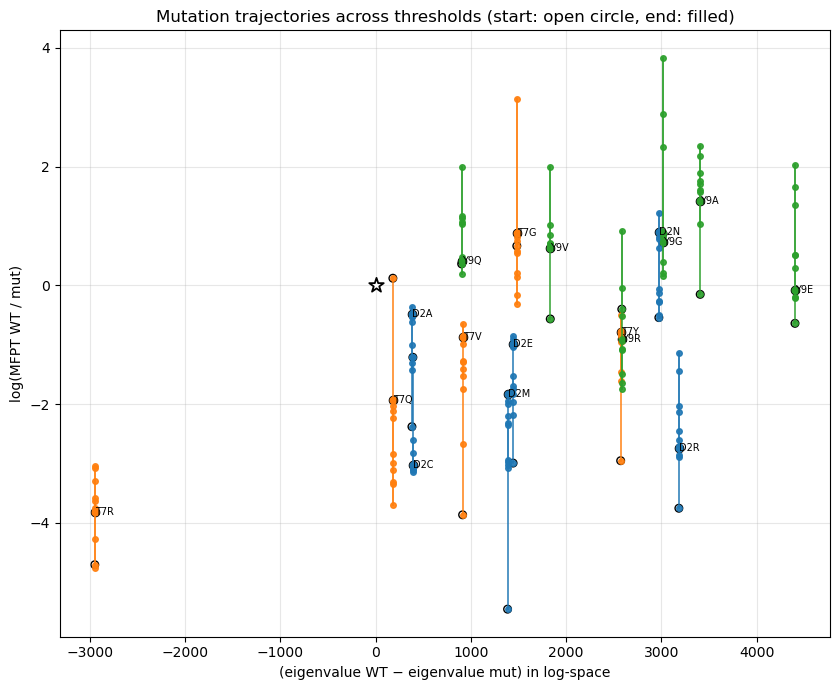

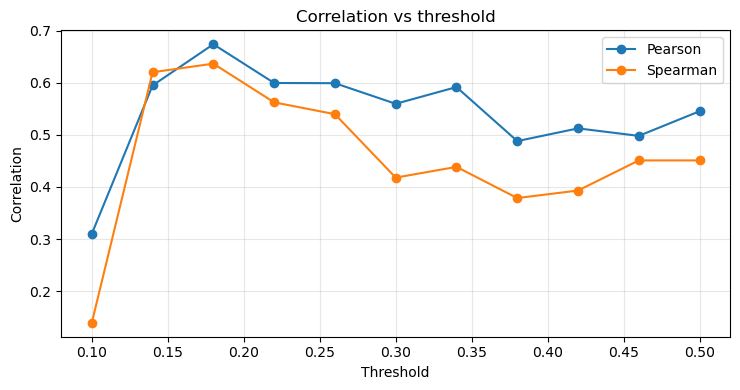

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import pickle
 
def plot_mfpt_trails(collect_df, all_mfpt, sample_size,
                     prop_col='eigenvalue', wt_label='WT',
                     group_col='residue_idx', log_prop=True,
                     annotate_end=True):

    thresholds = np.array(list(all_mfpt['chignolin'].keys()))
    # Build a df per threshold
    dfs = {th: collect_df(all_mfpt, th, sample_size) for th in thresholds}

    # Intersect indices so we track the same mutants across thresholds
    idx_common = set.intersection(*(set(df.index) for df in dfs.values()))
    if wt_label in idx_common:
        idx_common.remove(wt_label)  # we'll place WT separately at (0,0) if needed
    idx_common = sorted(idx_common)

    # Colors per residue
    # Try user color_map(res_keys), else assign from matplotlib
    res_keys = sorted({int(v) for df in dfs.values()
                       for v in df[group_col].dropna().unique()})
    if 'color_map' in globals():
        cmap = color_map(res_keys)
    else:
        base = plt.cm.get_cmap('tab20', len(res_keys))
        cmap = {k: base(i) for i, k in enumerate(res_keys)}

    def ratio_or_raw(wt, arr, use_log):
        arr = np.asarray(arr, float)
        if wt is None or (isinstance(wt, float) and np.isnan(wt)):
            return arr
        if use_log:
            if wt <= 0 or np.any(arr <= 0):
                raise ValueError(f"Nonpositive values in '{prop_col}' — log undefined.")
            return wt - arr
        return wt - arr

    # Precompute positions per mutant across thresholds
    trails = {}  # name -> dict(th -> (x, y))
    wt_xy = {}   # th -> (x_wt, y_wt) for plotting the WT star if desired

    for th, df in dfs.items():
        wt_mfpt = float(df.loc[wt_label, 'mfpt'])
        wt_prop = df.loc[wt_label, prop_col] if wt_label in df.index else np.nan

        # Save WT position (0,0 in log-ratio space if both defined)
        if not (isinstance(wt_prop, float) and np.isnan(wt_prop)):
            wt_xy[th] = (0 if log_prop else float(wt_prop), 0.0)
        else:
            wt_xy[th] = None

        # Compute per-mutant
        for name in idx_common:
            sub = df.loc[name]
            x = ratio_or_raw(wt_prop, np.array([sub[prop_col]]), log_prop)[0]
            y = np.log(wt_mfpt / float(sub['mfpt']))
            if name not in trails: trails[name] = {}
            trails[name][th] = (x, y)

    # Main figure: all thresholds as trajectories
    fig, ax = plt.subplots(figsize=(8.5, 7))
    for name in idx_common:
        # get residue idx + color
        any_df = next(iter(dfs.values()))
        res_id = any_df.loc[name, group_col]
        col = cmap.get(int(res_id), None)

        # order by thresholds for a clean path
        xy = np.array([trails[name][th] for th in thresholds if th in trails[name]])
        if xy.size == 0: 
            continue

        # draw trail
        ax.plot(xy[:,0], xy[:,1], marker='o', linewidth=1.2, markersize=4, alpha=0.9, c=col)

        # emphasize start/end
        ax.scatter(xy[0,0], xy[0,1], s=30, facecolors='none', edgecolors='k', linewidths=1.0)  # start = open circle
        ax.scatter(xy[-1,0], xy[-1,1], s=40, c=col, edgecolors='k', linewidths=0.6)           # end = filled

        # annotate end point
        if annotate_end:
            ax.text(xy[-1,0], xy[-1,1], name, fontsize=7, ha='left', va='center')

    # Optional: plot WT (0,0) once if defined
    if any(v is not None for v in wt_xy.values()):
        ax.scatter(0, 0, s=120, marker='*', edgecolors='k', linewidths=1.3, c='white', zorder=5, label=wt_label)

    xlabel = (f'({prop_col} WT − {prop_col} mut) in log-space'
              if log_prop else f'{prop_col} WT − {prop_col} mut')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('log(MFPT WT / mut)')
    ax.set_title('Mutation trajectories across thresholds (start: open circle, end: filled)')

    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    pearsons, spearmans = [], []
    
    for th, df in dfs.items():
        wt_mfpt = float(df.loc[wt_label, 'mfpt'])
        wt_prop = df.loc[wt_label, prop_col] if wt_label in df.index else np.nan

        x_all = ratio_or_raw(wt_prop, df[prop_col].to_numpy(), log_prop)
        y_all = np.log(wt_mfpt / df['mfpt'].to_numpy())
        mask = np.isfinite(x_all) & np.isfinite(y_all)

        p = stats.pearsonr(x_all[mask], y_all[mask])[0]
        s = stats.spearmanr(x_all[mask], y_all[mask])[0]
        pearsons.append(p); spearmans.append(s)

    fig2, ax2 = plt.subplots(figsize=(7.5, 4))
    ax2.plot(thresholds, pearsons, marker='o', label='Pearson')
    ax2.plot(thresholds, spearmans, marker='o', label='Spearman')
    ax2.set_xlabel('Threshold')
    ax2.set_ylabel('Correlation')
    ax2.set_title('Correlation vs threshold')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    plt.tight_layout()
    plt.show()


sample_size = 200
with open("../data/mfpt-pace=25000.pkl", "rb") as f:
    all_mfpt = pickle.load(f)


plot_mfpt_trails(
    collect_df=collect_df,
    all_mfpt=all_mfpt,
    sample_size=sample_size,
    prop_col='eigenvalue',
    wt_label='WT',
    group_col='residue_idx',
    log_prop=True,
    annotate_end=True
)

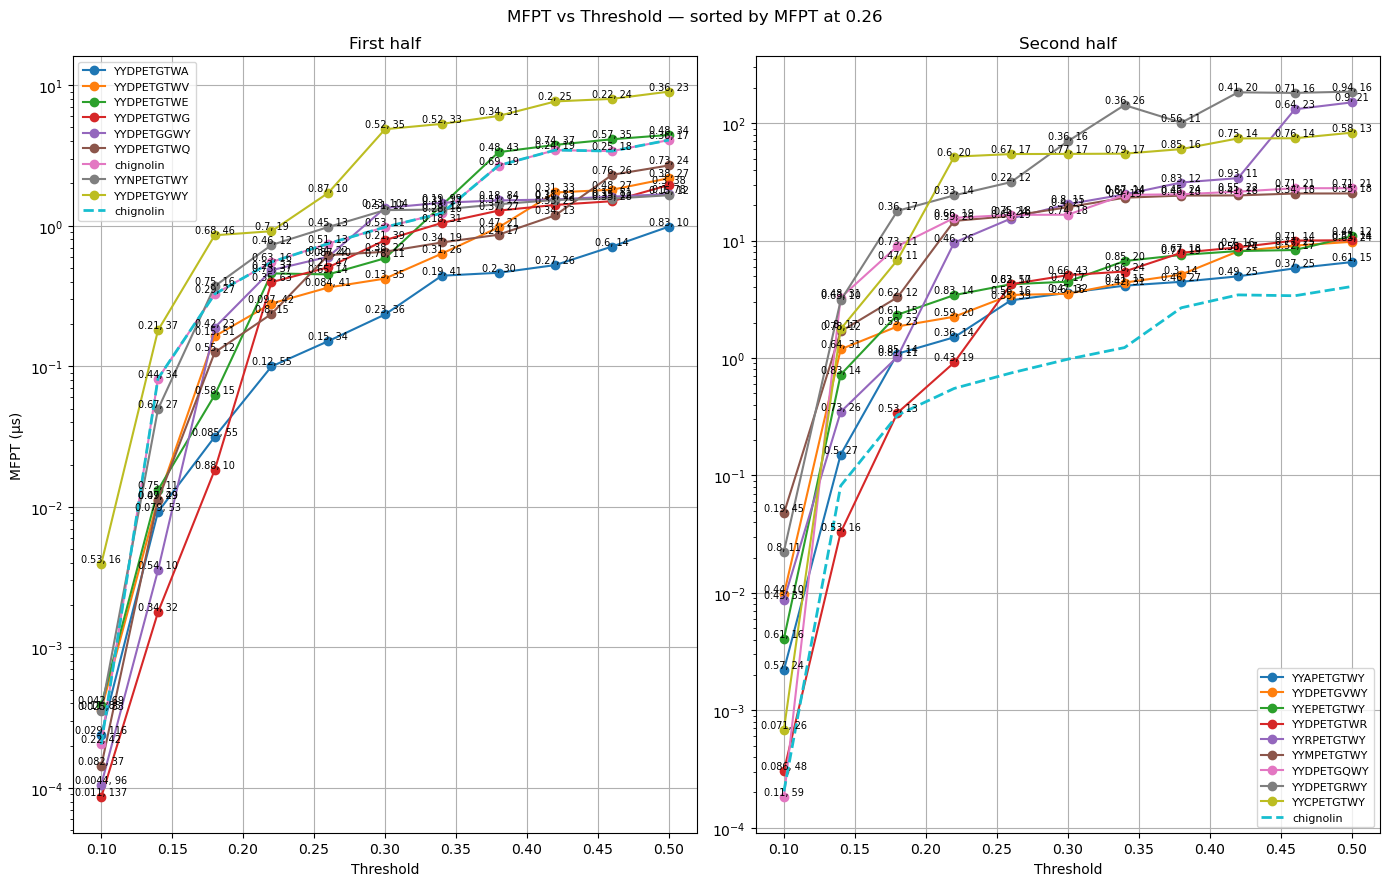

In [13]:
from scipy import stats, optimize


def fit_exp_ks(samples):
    x = np.array(samples)
    x.sort()

    n = x.size
    ecdf = np.arange(1, n + 1) / n
    def F(t, tau): return 1 - np.exp(-t / tau)
    
    tau = optimize.curve_fit(lambda t, tau: F(t, tau), x, ecdf, p0=(x.mean(),), bounds=(0, np.inf))[0][0]
    D, p = stats.kstest(x, "expon", args=(0, tau))
    return tau, p, D
    
def plot_all_mfpt(all_mfpt, proteins, sort_idx=4):
    """
    Sort proteins by ascending MFPT at thresholds[sort_idx] and plot side-by-side
    with independent y-scales and legends.
    """
    thresholds = np.array(list(all_mfpt['chignolin'].keys()))
    sort_idx = max(0, min(sort_idx, len(thresholds) - 1))

    # Collect MFPT (µs)
    series = {p: [] for p in proteins}
    pValues = {p: [] for p in proteins}
    chig = []

    for th in thresholds:
        s = np.sort(np.array(all_mfpt['chignolin'][th]))
        chig_mfpt, lim = estimateMFPT(s, 10)
        chig.append(chig_mfpt / 1e6)

        for p in proteins:
            s = np.sort(np.array(all_mfpt[p][th]))
            mfpt, lim = estimateMFPT(s, 10)
            series[p].append(mfpt / 1e6)
            tau, pValue, D = fit_exp_ks(s[:lim])

            pValues[p].append((pValue, lim))

    def sort_key(p):
        return series[p][sort_idx]

    proteins_sorted = sorted(proteins, key=sort_key)

    mid = (len(proteins_sorted) + 1) // 2
    halves = [proteins_sorted[:mid], proteins_sorted[mid:]]

    fig, axes = plt.subplots(1, 2, figsize=(14, 9), sharey=False)
    ref_th = thresholds[sort_idx]

    for ax, subset, title_suffix in zip(axes, halves, ['First half', 'Second half']):
        for p in subset:
            ax.plot(thresholds, series[p], marker='o', label=p)

            for x, y, (p, lim) in zip(thresholds,series[p], pValues[p]):
                ax.text(x, y, f"{p:.2g}, {lim}", ha='center', va='bottom', fontsize=7)

        ax.plot(thresholds, chig, linestyle='--', linewidth=2, label='chignolin')
        ax.set_xlabel('Threshold')
        ax.set_title(f'{title_suffix}')
        ax.set_yscale('log')
        ax.legend(fontsize=8, ncol=1)
        ax.grid(True)

    axes[0].set_ylabel('MFPT (µs)')
    fig.suptitle(f'MFPT vs Threshold — sorted by MFPT at {ref_th:.3g}')

    plt.tight_layout()
    plt.show()

plot_all_mfpt(all_mfpt, proteins)


0.18000000000000002
326685.17826737533 27


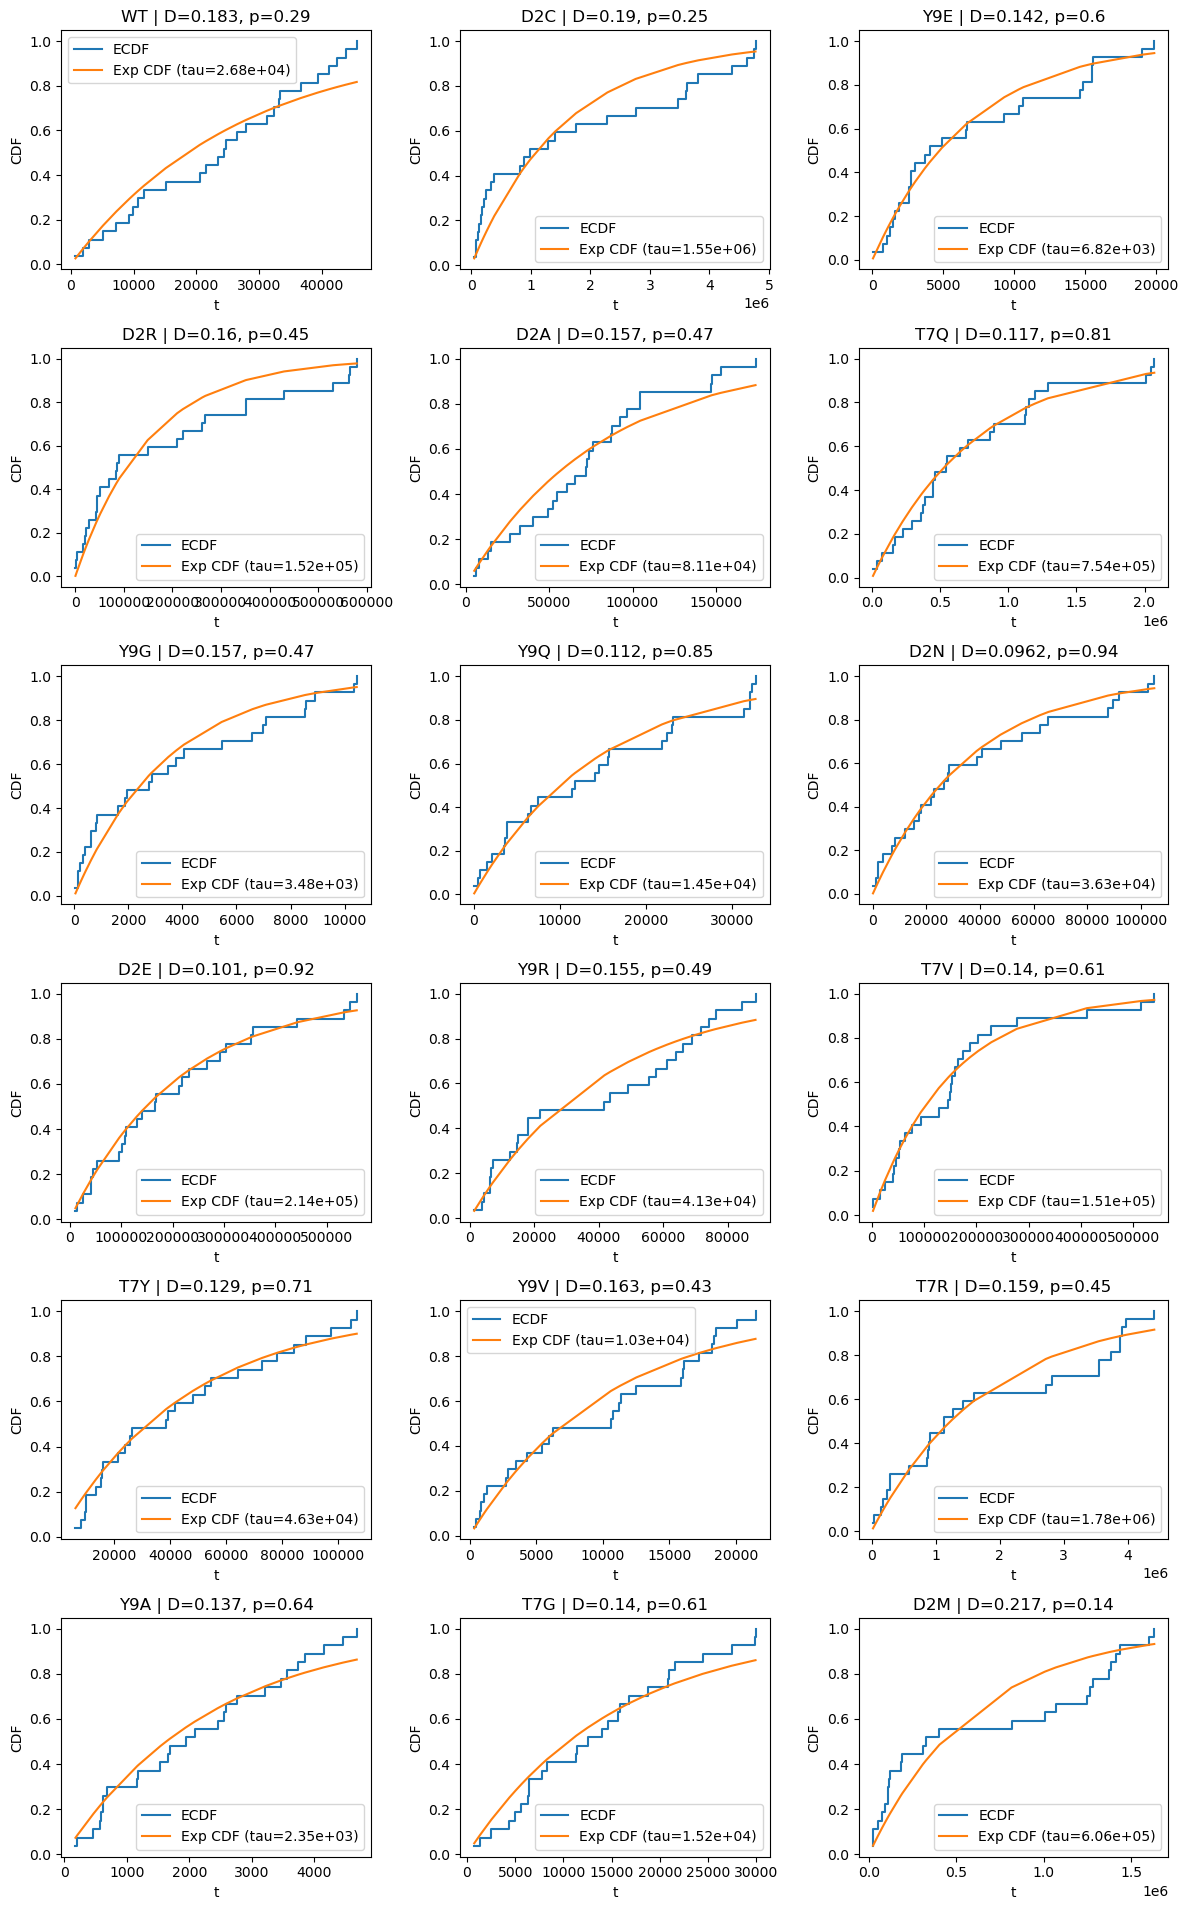

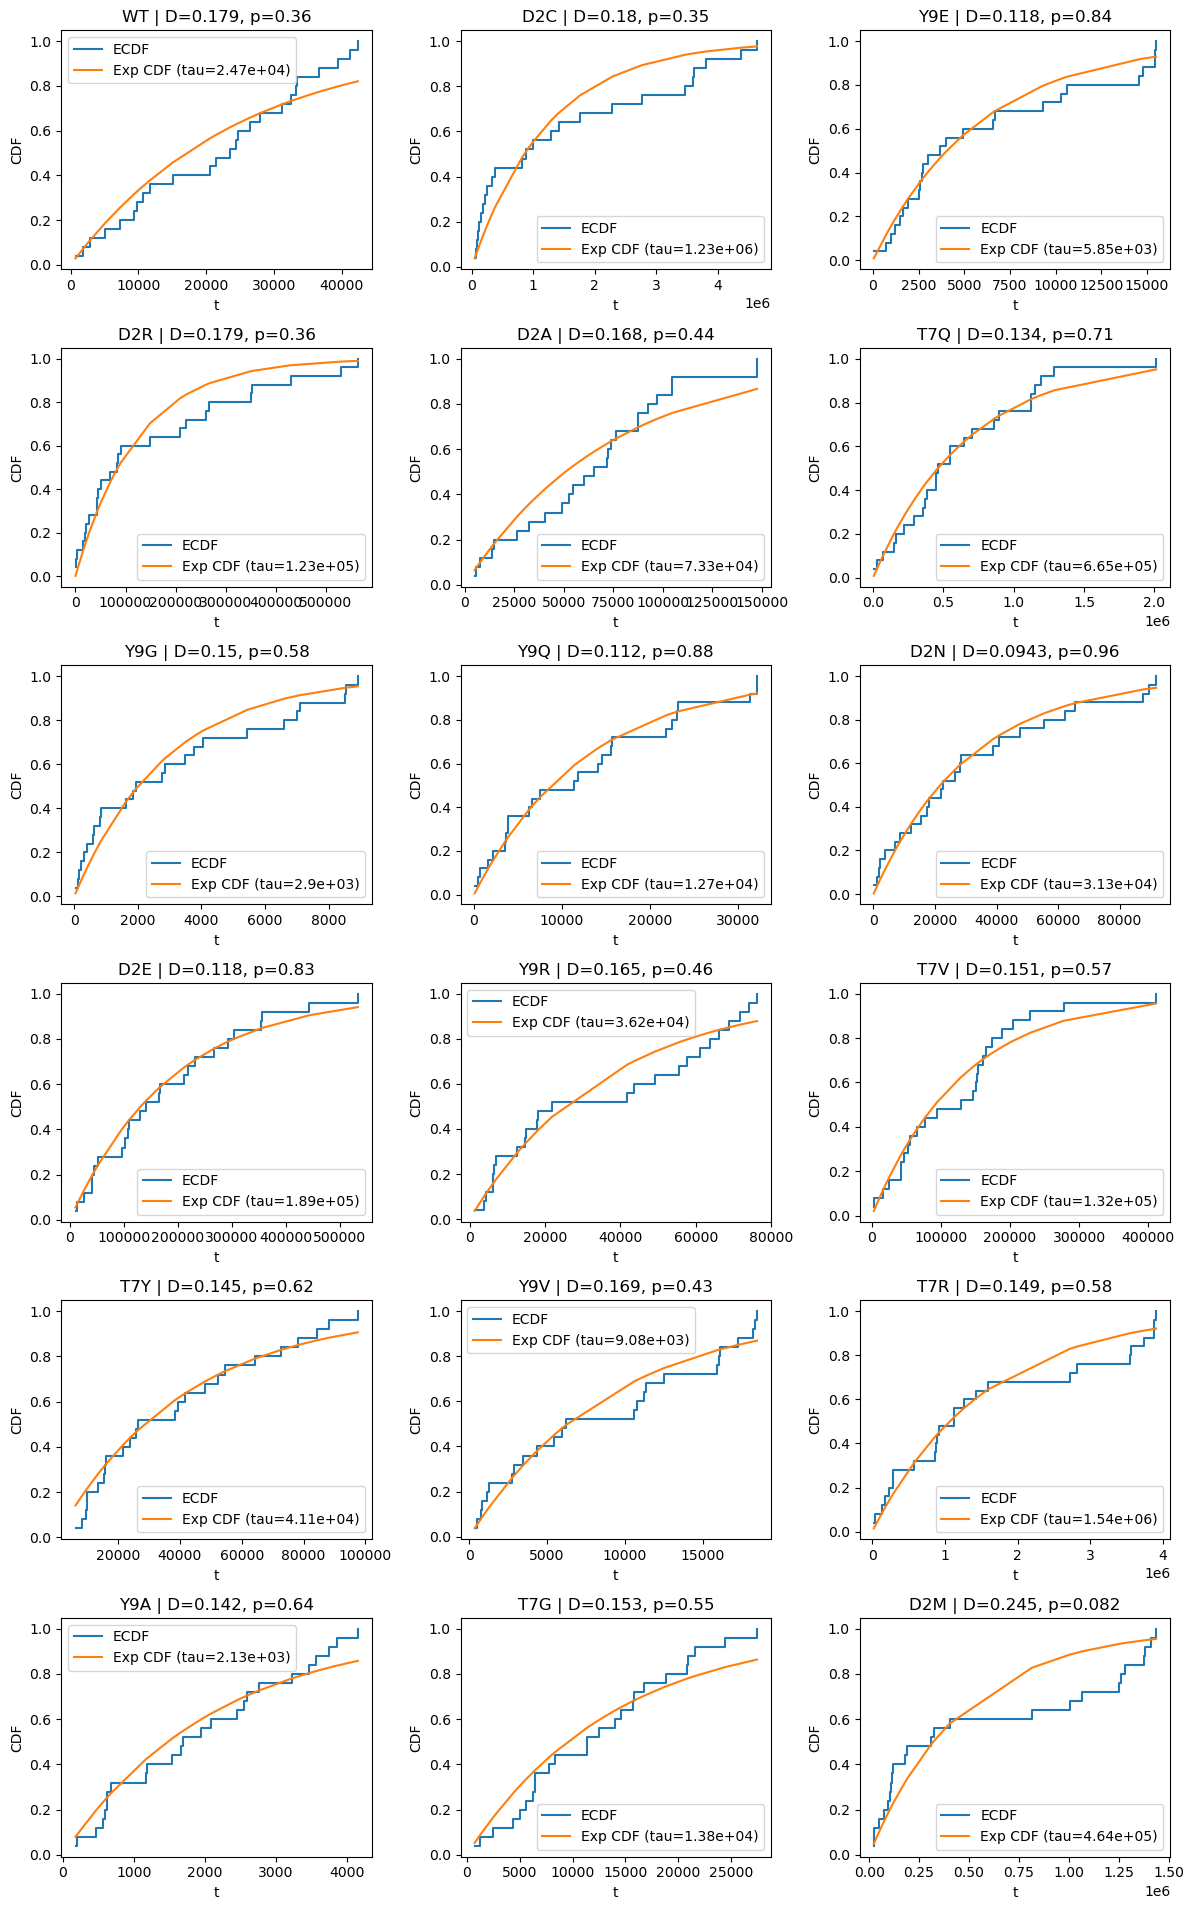

      name  k_fixed    tau_fixed  D_fixed  p_fixed  k_dyn       tau_dyn    D_dyn    p_dyn
 chignolin       25 2.465825e+04 0.179182 0.355447     27  26827.569517 0.182585 0.292091
YYCPETGTWY       25 1.232838e+06 0.180036 0.349887     11 188573.016359 0.241818 0.468849
YYDPETGTWE       25 5.847341e+03 0.117654 0.840019     15   2588.006282 0.190326 0.583908
YYRPETGTWY       25 1.227105e+05 0.178612 0.359183     11  26121.244847 0.179544 0.810501
YYAPETGTWY       25 7.331481e+04 0.167583 0.436422     14  38464.831865 0.154028 0.845523
YYDPETGQWY       25 6.654829e+05 0.134140 0.709932     11 242509.636467 0.194043 0.734101
YYDPETGTWG       25 2.896479e+03 0.150052 0.575373     10    411.010277 0.172156 0.881266
YYDPETGTWQ       25 1.268974e+04 0.112417 0.875568      5    820.129986 0.251110 0.841145
YYNPETGTWY       25 3.130773e+04 0.094278 0.964188     16  14360.612992 0.159487 0.753578
YYEPETGTWY       25 1.886313e+05 0.118445 0.834348     15  90473.350175 0.186754 0.607268
YYDPETGTWR

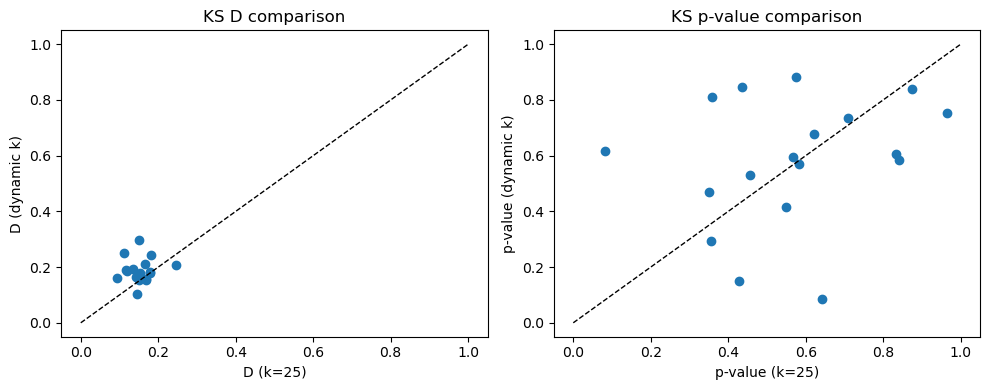

In [ ]:
import math 

def fit_exp_ecdf(samples, ax):
    x = np.array(samples)

    n = x.size
    def F(t, tau): return 1 - np.exp(-t / tau)
    ecdf = np.arange(1, n + 1) / n
    tau = optimize.curve_fit(lambda t, tau: F(t, tau), x, ecdf, p0=(x.mean(),), bounds=(0, np.inf))[0][0]
    th = stats.expon.cdf(x, scale=tau)

    ax.step(x, ecdf, where="post", label="ECDF")
    ax.plot(x, th, label=f"Exp CDF (tau={tau:.3g})")
    D, p = stats.kstest(x, "expon", args=(0, tau))
    ax.set_xlabel("t"); ax.set_ylabel("CDF"); ax.legend(); ax.set_title(f"D={D:.3g}, p={p:.2g}")
    return tau, D, p, ax

def ks_table_fastest_k(all_mfpt, names, th, k):
    rows = []
    for name in names:
        s = np.array(all_mfpt[name][th])
        s.sort()
        
        s = s[:k]
        tau, p, D = fit_exp_ks(s)
        rows.append({"name": name, "n": s.size, "tau": tau, "ks_p": p, "ks_D": D})
    return pd.DataFrame(rows).sort_values("ks_p", ascending=False)

def plot_ecdfs_grid_fastest_k(all_mfpt, names, th, k = None ):
    ncols=3
    m = len(names)
    nrows = math.ceil(m / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.2*nrows), squeeze=False)
    for i, name in enumerate(names):
        r, c = divmod(i, ncols)
        if k == None:
            mfpt_base, k = estimateMFPT(np.array(all_mfpt[name][th]), 10)
            print(mfpt_base, k)

        s = np.sort(np.array(all_mfpt[name][th]))[:k]
        fit_exp_ecdf(s, ax=axes[r, c])
        axes[r, c].set_title(f"{mutation_map[name]} | " + axes[r, c].get_title())
        
    fig.tight_layout()
    return fig

th = np.array(list(all_mfpt['chignolin'].keys()))[2]
print(th)
names = list(proteins)
k = 25
res = ks_table_fastest_k(all_mfpt, names, th, k = k)

plot_ecdfs_grid_fastest_k(all_mfpt, names, th)
plt.show()

plot_ecdfs_grid_fastest_k(all_mfpt, names, th, k = k)
plt.show()

def compare_k_vs_dynamic(all_mfpt, names, th, k = k):
    rows = []
    for name in names:
        s_all = np.sort(np.array(all_mfpt[name][th]))

        s_fixed = s_all[:k]
        fig, ax = plt.subplots()
        tau_f, D_f, p_f, _ = fit_exp_ecdf(s_fixed, ax=ax)
        plt.close(fig)

        # Dynamic k from estimateMFPT
        _, k_dyn = estimateMFPT(s_all, 5)
        s_dyn = s_all[:k_dyn]
        fig, ax = plt.subplots()
        tau_d, D_d, p_d, _ = fit_exp_ecdf(s_dyn, ax=ax)
        plt.close(fig)

        rows.append({
            "name": name,
            "k_fixed": k, "tau_fixed": tau_f, "D_fixed": D_f, "p_fixed": p_f,
            "k_dyn": k_dyn, "tau_dyn": tau_d, "D_dyn": D_d, "p_dyn": p_d
        })

    df = pd.DataFrame(rows)
    print(df.to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].scatter(df["D_fixed"], df["D_dyn"])
    axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[0].set_xlabel(f"D (k={k})")
    axes[0].set_ylabel("D (dynamic k)")
    axes[0].set_title("KS D comparison")

    axes[1].scatter(df["p_fixed"], df["p_dyn"])
    axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[1].set_xlabel(f"p-value (k={k})")
    axes[1].set_ylabel("p-value (dynamic k)")
    axes[1].set_title("KS p-value comparison")

    fig.tight_layout()
    return df, fig

df_comparison, fig_cmp = compare_k_vs_dynamic(all_mfpt, names, th)
plt.show()


In [17]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize, stats
from common.utils import estimateMFPT
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

PROTEINS = ['YYAPETGTWY','YYCPETGTWY','YYDPETGQWY', 'YYDPETGRWY']
RANGES = [(4000, 4200), (3000, 3200), (3201, 3400)]
THRESHOLDS = np.round(np.arange(0.1, 0.5 + 1e-9, 0.05), 2)

def read_colvar(path: Path) -> pd.DataFrame:
    with path.open() as f:
        for line in f:
            if line.startswith("#! FIELDS"):
                names = line.replace("#! FIELDS", "").strip().split()
                break
        else:
            raise ValueError(f"No FIELDS header in {path}")
    return pd.read_csv(path, sep=r"\s+", comment="#", names=names, engine="python")

def first_cross_times(df: pd.DataFrame, thresholds):
    rmsd = df['rmsd'].to_numpy()
    t = df['time'].to_numpy()
    acc = df['metad.acc'].to_numpy()
    out = {}
    for th in thresholds:
        idx = np.flatnonzero(rmsd > th)
        out[float(th)] = None if idx.size == 0 else float(t[idx[0]] * acc[idx[0]])
    return out

def fit_tau_and_pvalue(samples):
    x = np.array(sorted(samples, key=float))
    n = len(x)
    ecdf = np.arange(1, n + 1) / n
    tau = optimize.curve_fit(lambda tt, tau: 1 - np.exp(-tt / tau), x, ecdf, p0=(x.mean(),), bounds=(0, np.inf))[0][0]
    f = np.random.exponential(tau, size=max(10000, 10*n))
    p = stats.ks_2samp(x, f, alternative="two-sided", method="asymp")[1]
    return tau, p

def gather_samples_multi(protein: str, start: int, stop: int, thresholds):
    base = Path(f"../data/{protein}/output")
    buckets = {float(th): [] for th in thresholds}
    for i in range(start, stop):
        p = base / f"run_{i}" / f"HLDA_COLVAR_{i}"
        if not p.exists():
            print(f"Missing file: {p}")
            continue
        df = read_colvar(p)
        crosses = first_cross_times(df, thresholds)
        for th, val in crosses.items():
            if val is not None:
                buckets[th].append(val)
    rows = []
    for th, arr in buckets.items():
        if not arr:
            rows.append(dict(thresh=th, mfpt=None, k=None, pvalue=None, n=0))
            continue
        arr = np.array(arr, float)
        mfpt, k = estimateMFPT(arr, 15)
        tau, pval = fit_tau_and_pvalue(arr)
        rows.append(dict(thresh=th, mfpt=mfpt, k=k, pvalue=pval, n=len(arr)))
    return pd.DataFrame(rows)

all_rows = []
for protein in PROTEINS:
    for (a, b) in RANGES:
        res = gather_samples_multi(protein, a, b, THRESHOLDS)
        res['protein'] = protein
        res['start'] = a
        res['stop'] = b
        all_rows.append(res)

res = pd.concat(all_rows, ignore_index=True)
print(res)

fig1, axes1 = plt.subplots(len(PROTEINS), 1, figsize=(6, 4*len(PROTEINS)), squeeze=False)
for ax, protein in zip(axes1.ravel(), PROTEINS):
    sub = res[(res.protein==protein) & res.mfpt.notna()]
    for (a,b), g in sub.groupby(["start","stop"]):
        g = g.sort_values("thresh")
        ax.plot(g.thresh, g.mfpt*1e-6, marker="o", label=f"{a}-{b-1}")
    ax.set_title(f"{protein} — MFPT vs threshold")
    ax.set_xlabel("threshold")
    ax.set_ylabel("MFPT (µs)")
    ax.legend()
plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(len(PROTEINS), 1, figsize=(6, 4*len(PROTEINS)), squeeze=False)
for ax, protein in zip(axes2.ravel(), PROTEINS):
    sub = res[(res.protein==protein) & res.pvalue.notna()]
    for (a,b), g in sub.groupby(["start","stop"]):
        g = g.sort_values("thresh")
        ax.plot(g.thresh, g.pvalue, marker="s", label=f"{a}-{b-1}")
    ax.set_title(f"{protein} — KS p-value vs threshold")
    ax.set_xlabel("threshold")
    ax.set_ylabel("p-value")
    ax.legend()
plt.tight_layout()
plt.show()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


KeyboardInterrupt: 